In [1]:
%pip install ipywidgets
%pip install IPython
%pip install json
%pip install pathlib
%pip install numpy
%pip install sys
%pip install pandas
%pip install matplotlib
%pip install seaborn
%matplotlib inline
%pip install cupy


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/3.9 MB ? eta -:--:--
      --------------------------------------- 0.1/3.9 MB 1.7 MB/s eta 0:00:03
     - -------------------------------------- 0.1/3.9 MB 1.2 MB/s eta 0:00:04
     -- ------------------------------------- 0.2/3.9 MB 1.8 MB/s eta 0:00:03
     --- ------------------------------------ 0.4/3.9 MB 2.2 MB/s eta 0:00:02
     ----- ---------------------------------- 0.5/3.9 MB 2.2 MB/s eta 0:00:02
     ------- -------------------------------- 0.7/3.9 MB 2.5 MB/s eta 0:00:02
     -------- ------------------------------- 0.9/3.9 MB 2.6 MB/s eta 0:00:02
     ---------- ----------------------------- 1.0/3.9 MB 2.7 MB/s eta 0:00:02
     ----------- ---------------------------- 1.2/3.9 MB 2.7 MB/s eta 0:00:02
     ------------- -------------------------- 1.3/3.9 MB 2.9 MB/s eta 0:00:01
     --------------- ------------------------ 1.5/3.9 MB 2.9 MB/s eta 0:00:01
     

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [69 lines of output]
      Generating CUPY_CACHE_KEY from header files...
      CUPY_CACHE_KEY (2006 files matching C:\Users\julie\AppData\Local\Temp\pip-install-sxsfoxby\cupy_d574b68521d544ddb4ef24a8daeef5d3\cupy\_core\include\**): f0aff8b0140d99853e8aff1d8ba78166f39f3c73
      Looking for NVTX from: []
      NVTX could not be found
      
      -------- Configuring Module: cuda --------
      a.cpp
      C:\Users\julie\AppData\Local\Temp\tmpg0dm5fp3\a.cpp(1): fatal error C1083: Cannot open include file: 'cublas_v2.h': No such file or directory
      command 'C:\\Program Files (x86)\\Microsoft Visual Studio\\2022\\BuildTools\\VC\\Tools\\MSVC\\14.43.34808\\bin\\HostX86\\x64\\cl.exe' failed with exit code 2
      a.cpp
      C:\Users\julie\AppData\Local\Temp\tmp0w29h4pj\a.cpp(2): fatal error C1083: Cannot open include file: 'cuda_runtime_api.h': No such file 

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
from pathlib import Path
from scipy.signal import savgol_filter

import numpy as np
import sys
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


project_root = Path("..").resolve()
sys.path.append(str(project_root))
from Calibration.Parameters import CHAMBERS_COLORS


## Résultats pour une larve individuelle

<div style="
background-color:#000000;
padding:12px;
border-radius:6px;
border:1px solid #000000;
">

###  Paramètres à définir

Veuillez entrer le numéro d'expérience, ainsi que le numéro du labyrinthe d'étude

In [2]:
lab_letters = ["A","B","C","D","E","F","G","H"]
lab_position = ["top","bottom"]

project_root = Path("..").resolve()
data_folder = project_root / "Data"

experiment_folders = sorted([f.name for f in data_folder.iterdir() if f.is_dir()])

exp_dropdown = widgets.Dropdown(
    options=experiment_folders,
    description='Expérience:',
    style={'description_width':'initial'}
)

letter_dropdown = widgets.Dropdown(
    options=lab_letters,
    value=lab_letters[0],
    description='Labyrinthe:',
    style={'description_width':'initial'}
)

position_dropdown = widgets.Dropdown(
    options=lab_position,
    value=lab_position[0],
    description='Partie:',
    style={'description_width':'initial'}
)

validate_button = widgets.Button(description='Valider', button_style='success')
output = widgets.Output()


def on_validate_clicked(b):

    with output:

        clear_output()

        Experiment = exp_dropdown.value
        Double_Maze = letter_dropdown.value
        Maze = position_dropdown.value

        Mazes_name = f"Maze_{Double_Maze}"
        Maze_name = f"Maze_{Double_Maze}_{Maze}"

        print(f"Expérience choisie: {Experiment}")
        print(f"Labyrinthe choisi: {Maze_name}")

        tracking_file = data_folder / Experiment / "Video" / "Mazes" / Mazes_name / f"{Maze_name}_tracking.json"

        print("Chemin :", tracking_file)

        if not tracking_file.exists():
            print("Attention, fichier introuvable")
            return

        # Charger le tracking
        with open(tracking_file) as f:
            data = json.load(f)

        fps = data["fps"]

        df = pd.DataFrame(data["tracking"])

        df["x"] = df["position"].apply(lambda p: p["x"] if p else None)
        df["y"] = df["position"].apply(lambda p: p["y"] if p else None)

        df = df.drop(columns="position")

        print("Tracking chargé avec succès !")


validate_button.on_click(on_validate_clicked)
ui = widgets.VBox([
    exp_dropdown,
    widgets.HBox([letter_dropdown, position_dropdown, validate_button]),
    output
])
display(ui)

In [35]:
Experiment = exp_dropdown.value
Double_Maze = letter_dropdown.value
Maze = position_dropdown.value

Mazes_name = f"Maze_{Double_Maze}"
Maze_name = f"Maze_{Double_Maze}_{Maze}"

tracking_video = (
    project_root
    / "Data"
    / Experiment
    / "Video"
    / "Mazes"
    / Mazes_name
    / f"{Maze_name}.mp4"
)

cap = cv2.VideoCapture(str(tracking_video))
    
ret, frame = cap.read()

if not ret:
    video_width, video_height = 888, 930
    print(f"Aucune vidéo trouvée, la taille a été initialisée manuellement")
else:
    video_height, video_width = frame.shape[:2]

cap.release()

print(f"Taille vidéo : {video_width} x {video_height}")


Aucune vidéo trouvée, la taille a été initialisée manuellement
Taille vidéo : 888 x 930


In [36]:
mask_path_top = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_top_painted.png"
mask_path_bottom = project_root / "Calibration" / "Maze_pictures" / "Maze_mask_bottom_painted.png"

mask_top = cv2.imread(str(mask_path_top))
mask_bottom = cv2.imread(str(mask_path_bottom))
mask_top = cv2.cvtColor(mask_top, cv2.COLOR_BGR2RGB)
mask_bottom = cv2.cvtColor(mask_bottom, cv2.COLOR_BGR2RGB)


mask_top = cv2.resize(
    mask_top,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

mask_bottom = cv2.resize(
    mask_bottom,
    (video_width, video_height),
    interpolation=cv2.INTER_NEAREST
)

if Maze == "top":
    mask_resized = mask_top
else:
    mask_resized = mask_bottom

In [37]:
tracking_file = project_root / "Data" / Experiment / "Video" / "Mazes" / Mazes_name / f"{Maze_name}_tracking.json"

with open(tracking_file) as f:
    data = json.load(f)

fps = data["fps"]
tracking = data["tracking"]

df = pd.DataFrame(tracking)
df["x"] = df["position"].apply(lambda p: p["x"] if p else None)
df["y"] = df["position"].apply(lambda p: p["y"] if p else None)
df = df.drop(columns="position")

print("Tracking chargé :", df.shape, "frames")


Tracking chargé : (21602, 7) frames


## Zones de visites

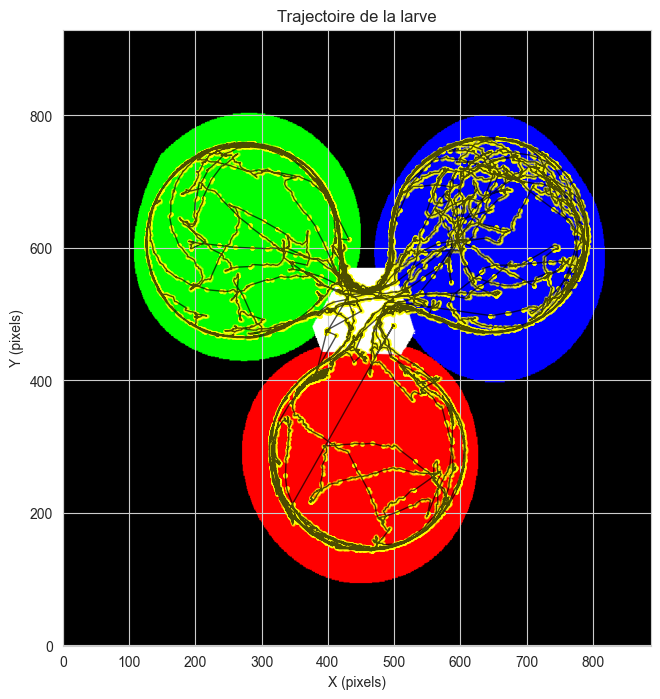

In [45]:
COLOR_MAP = { "Red": (255,0,0), "Green": (0,255,0), "Blue": (0,0,255), "White": (255,255,255) }

CHAMBERS_RGB = { chamber: COLOR_MAP[color] for chamber, color in CHAMBERS_COLORS.items() }

chamber_index = { "Chambre_1": 1, "Chambre_3": 3, "Chambre_2": 2, "Decision_zone": 4 }

chamber_map = np.zeros(mask_resized.shape[:2], dtype=int)

for chamber, rgb in CHAMBERS_RGB.items():
    mask_pixels = np.all(mask_resized == rgb, axis=2)
    chamber_map[mask_pixels] = chamber_index[chamber]
plt.figure(figsize=(8, 8))
plt.imshow(mask_resized)
plt.title("Trajectoire de la larve")
plt.plot(df["x"], df["y"], color='black', linewidth=1, alpha=0.7)
plt.scatter(df["x"], df["y"], color='yellow', s=5, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.show()

In [39]:
df["x_int"] = df["x"].astype("Int64")
df["y_int"] = df["y"].astype("Int64")

height, width = chamber_map.shape

df["chamber_id"] = [
    chamber_map[y, x]
    if pd.notna(x) and pd.notna(y) and 0 <= x < width and 0 <= y < height
    else 0
    for x, y in zip(df["x_int"], df["y_int"])
]
inverse_map = {v:k for k,v in chamber_index.items()}
inverse_map[0] = "Outside"

df["chamber"] = df["chamber_id"].map(inverse_map)

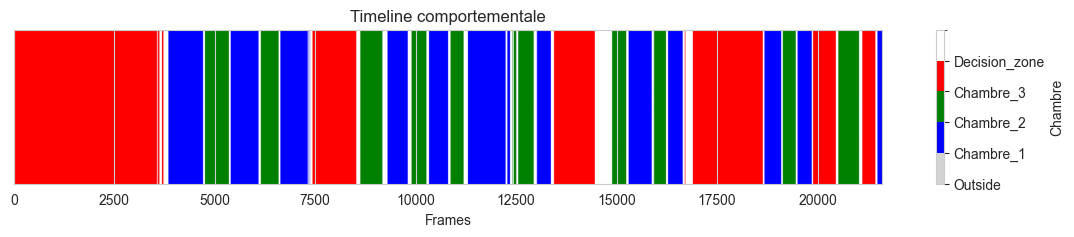

In [40]:
colors = {
    0: "lightgray",# Outside
    1: "blue",# Chambre_1
    2: "green",# Chambre_2
    3: "red",# Chambre_3         
    4: "white"# Decision_zone                     
}

cmap = mcolors.ListedColormap([colors[i] for i in sorted(colors.keys())])
bounds = np.array(sorted(colors.keys()) + [max(colors.keys())+1])
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(14, 2))
plt.imshow(
    df["chamber_id"].values.reshape(1, -1),
    aspect="auto",
    cmap=cmap,
    norm=norm
)

plt.yticks([])

cbar = plt.colorbar(ticks=list(colors.keys()), orientation="vertical")
cbar.ax.set_yticklabels([inverse_map[i] for i in sorted(colors.keys())])
cbar.set_label("Chambre")

plt.xlabel("Frames")
plt.title("Timeline comportementale")
plt.show()

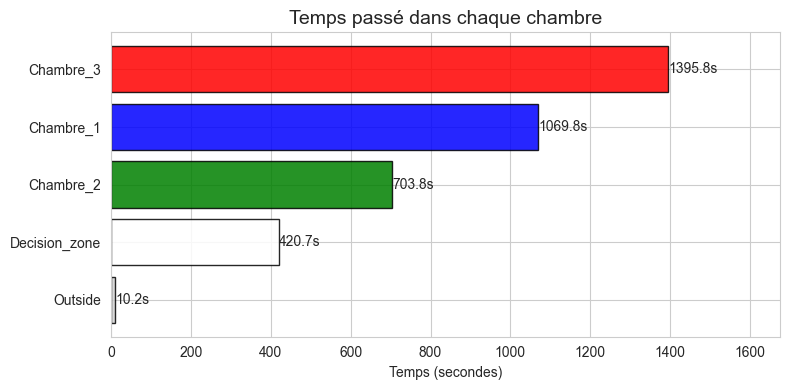

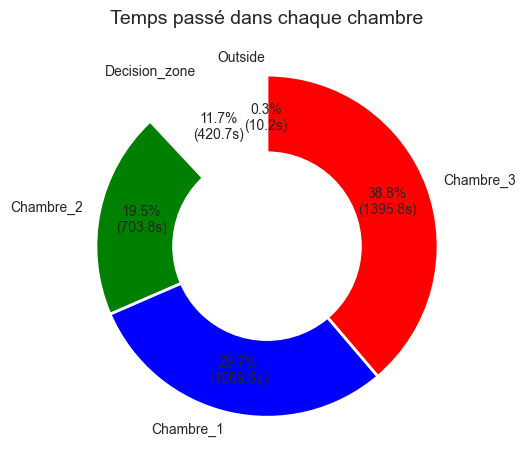

In [41]:
time_spent_sec = df.groupby("chamber").size() / fps

colors = {
    0: "lightgray",  # Outside
    1: "blue",       # Chambre_1
    2: "green",      # Chambre_2
    3: "red",        # Chambre_3
    4: "white"       # Decision_zone
}
name_to_key = {
    "Outside": 0,
    "Chambre_1": 1,
    "Chambre_2": 2,
    "Chambre_3": 3,
    "Decision_zone": 4
}

sorted_times = time_spent_sec.sort_values()

bar_colors = [colors[name_to_key[ch]] for ch in sorted_times.index]
sns.set_style("whitegrid")
plt.figure(figsize=(8,4))
bars = plt.barh(sorted_times.index, sorted_times.values, color=bar_colors, edgecolor='black', alpha=0.85)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}s", va='center', fontsize=10)

plt.xlabel("Temps (secondes)")
plt.title("Temps passé dans chaque chambre", fontsize=14)
plt.xlim(0, max(sorted_times.values)*1.2)
plt.tight_layout()
plt.show()



# Reprendre le même ordre que le barplot
pie_labels = sorted_times.index
pie_values = sorted_times.values

# Couleurs cohérentes
pie_colors = [colors[name_to_key[ch]] for ch in pie_labels]

wedges, texts, autotexts = plt.pie(
    pie_values,
    labels=pie_labels,
    colors=pie_colors,
    autopct=lambda p: f'{p:.1f}%\n({p/100*sum(pie_values):.1f}s)',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Effet donut
centre_circle = plt.Circle((0,0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Temps passé dans chaque chambre", fontsize=14)
plt.tight_layout()
plt.show()


chamber
Chambre_1        15208.483398
Chambre_2        10213.332402
Chambre_3        13381.787335
Decision_zone     4231.883967
Outside             14.064495
Name: distance_px, dtype: float64


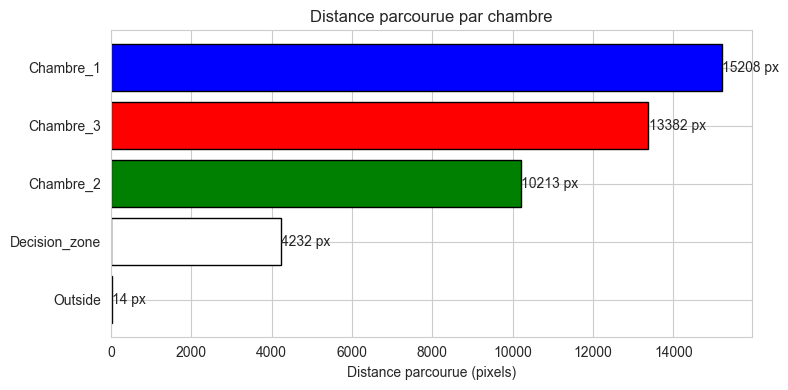

In [42]:
df["same_chamber"] = df["chamber"] == df["chamber"].shift(1)
distance_by_chamber = df[df["same_chamber"]].groupby("chamber")["distance_px"].sum()
print(distance_by_chamber)

colors = {
    "Outside": "lightgray",
    "Chambre_1": "blue",
    "Chambre_2": "green",
    "Chambre_3": "red",
    "Decision_zone": "white"
}

sorted_dist = distance_by_chamber.sort_values()

plt.figure(figsize=(8,4))

bars = plt.barh(
    sorted_dist.index,
    sorted_dist.values,
    color=[colors[ch] for ch in sorted_dist.index],
    edgecolor='black'
)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f"{width:.0f} px", va='center')

plt.xlabel("Distance parcourue (pixels)")
plt.title("Distance parcourue par chambre")

plt.tight_layout()
plt.show()

C:\Users\julie\AppData\Local\Temp\ipykernel_34056\1678079243.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


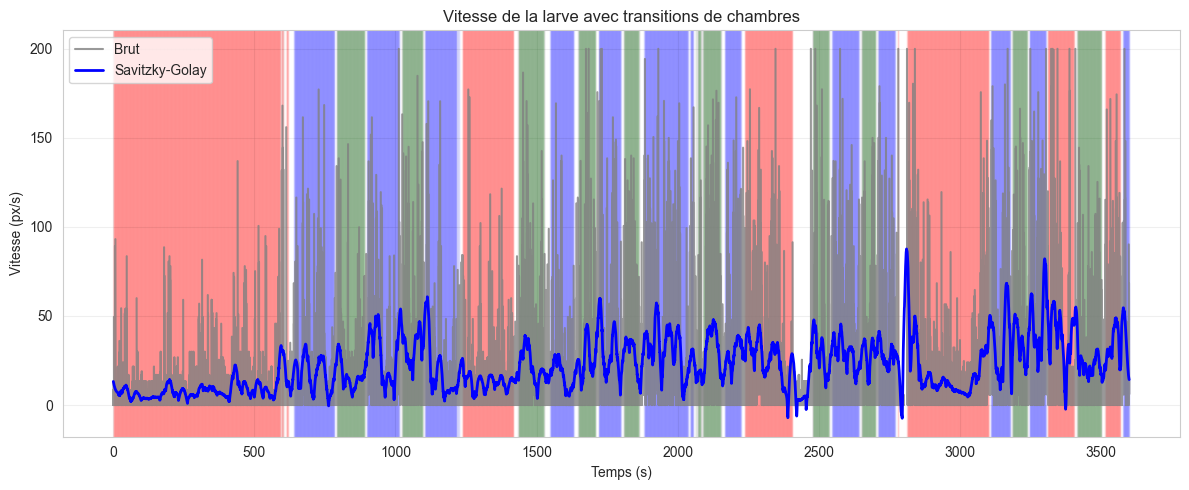

In [43]:
df["speed_px_per_sec"] = pd.to_numeric(df["speed_px_per_sec"], errors="coerce")
df["speed_clean"] = df["speed_px_per_sec"].clip(upper=200)
df["speed_interp"] = df["speed_clean"].interpolate()
df["speed_sg"] = savgol_filter(
    df["speed_interp"],
    window_length=201,   # impair
    polyorder=3)

df["chamber_change"] = df["chamber"] != df["chamber"].shift(1)
change_times = df.loc[df["chamber_change"], "time_sec"]
change_chambers = df.loc[df["chamber_change"], "chamber"]

plt.figure(figsize=(12,5))

plt.plot(df["time_sec"], df["speed_clean"], color='gray', alpha=0.8, label="Brut")
plt.plot(df["time_sec"], df["speed_sg"], color='blue', linewidth=2, label="Savitzky-Golay")

chamber_colors = {
    "Outside": "lightgray",
    "Chambre_1": "blue",
    "Chambre_2": "green",
    "Chambre_3": "red",
    "Decision_zone": "white"
}

for i in range(len(df)-1):
    plt.axvspan(
        df["time_sec"].iloc[i],
        df["time_sec"].iloc[i+1],
        color=chamber_colors.get(df["chamber"].iloc[i], "gray"),
        alpha=0.01
    )

# Labels
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse (px/s)")
plt.title("Vitesse de la larve avec transitions de chambres")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()